# Problem Types

Quantum Launcher provides a set of definitions of predefined combinatorial problems ready to use. Featured problems include Exact Cover, Graph Coloring, Job Shop Scheduling Problem, Max Cut, Quantum Air Traffic Management and Traveling Salesperson Problem

In [1]:
from quantum_launcher.problems import MaxCut,EC,QATM,JSSP,TSP, GraphColoring
import os

You can create you own problem instance but quantum launcher provides also example instances allowing to quickly test functionality.

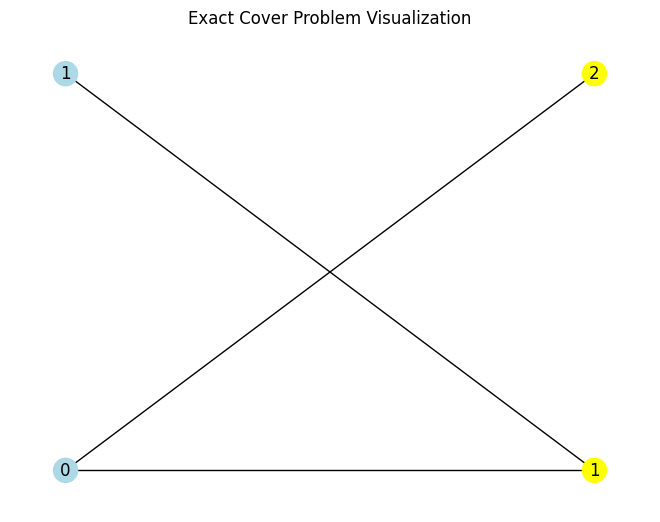

In [2]:
instance = [{1,2},{1}]
ec = EC(instance)
ec.visualize()

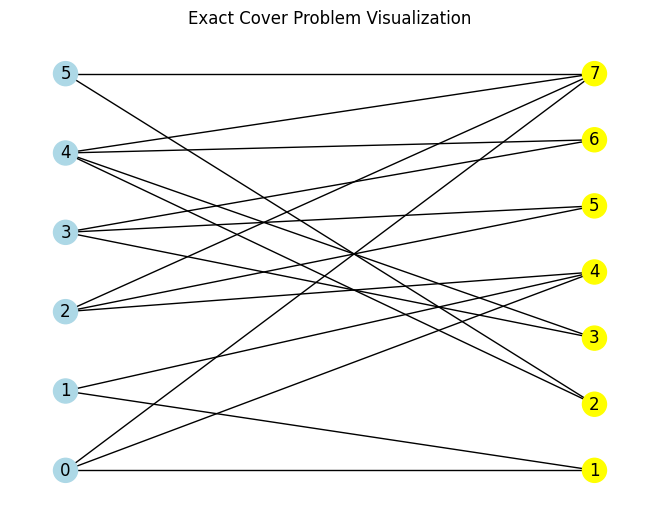

In [3]:
ec = EC.from_preset("toy")
ec.visualize()

As you can see you can easily visualize the problem instance by calling visualize() method, you can can also visualize an example solution.

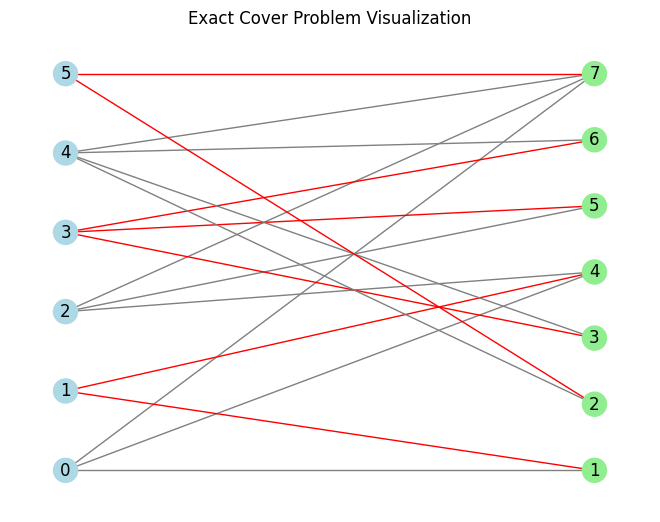

In [4]:
ec.visualize("010101")

Problem instances can be also randomly generated. 

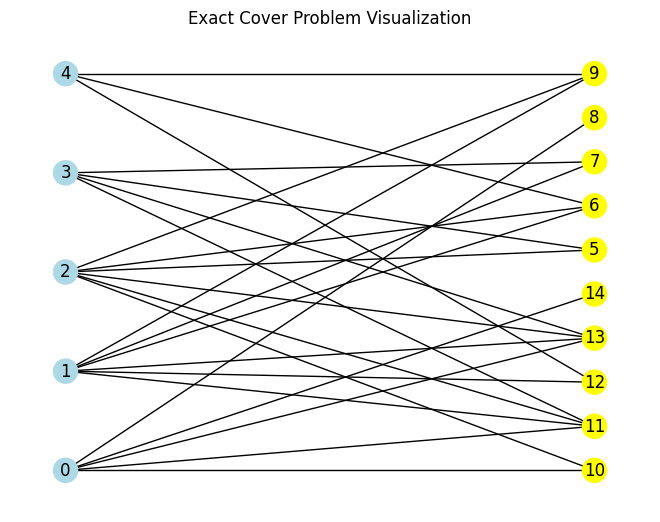

In [5]:
ec = EC.generate_ec_instance(5,10,0.4)
ec.visualize()

All problems problems already implemented in the quantum launcher are presented below:

## Max Cut
Max Cut is a combinatorial optimization problem in which the goal is to separate graph vertices into two subsets such that the number of edges connecting vertices in different subsets is maximized.

Formally, solving a max Cut problem is equivalent to maximizing profit function 

$$\min C(x) = \sum_{i,j}x_{i}(1-x_{j}) $$

where $x_{i} = 0$ if vertex x belongs to first subset and $x_{i}=1$ if vertex x belongs to the second subset.

the bits in the encoding of solution correspond to the assignment of the respective vertices

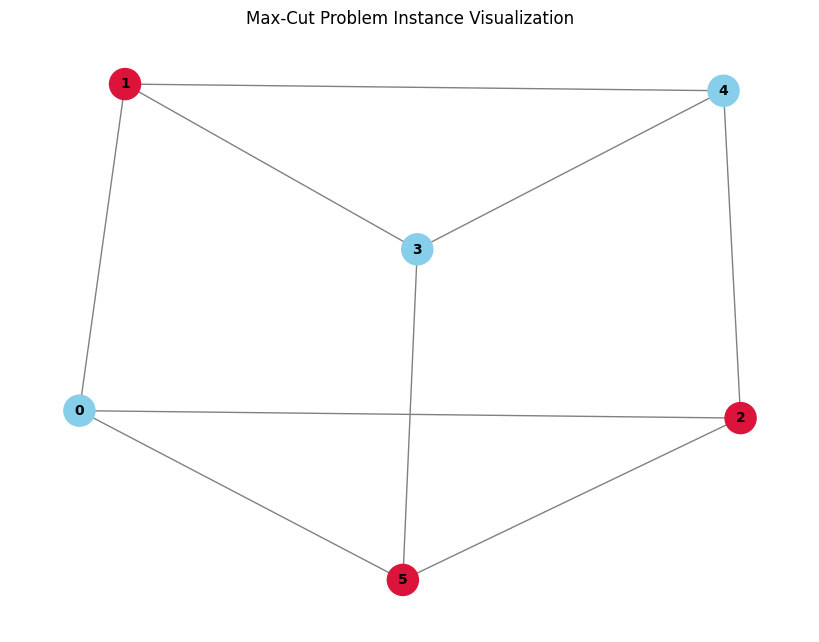

In [6]:
mc = MaxCut.from_preset('default')
mc.visualize('011001')

## Exact Cover

Exact cover is a collection $S$ of subsets of a set $X$ such that each element in $X$ is contained in exactly one subset in $S$. It can be visualized on a bipartite graph such that elements from the left set represent the subsets and elements from the right set represent the elements in $X$. In this case solving the the exact cover problem is equivalent to finding a subset of elements from the left set such that each element from the right one is connected to exactly one element from the the selected subset

in the encoding of the solution each bit represents a subset (or node from the left set in the bipartite representation), $1$ indicates that such subset/node is chosen

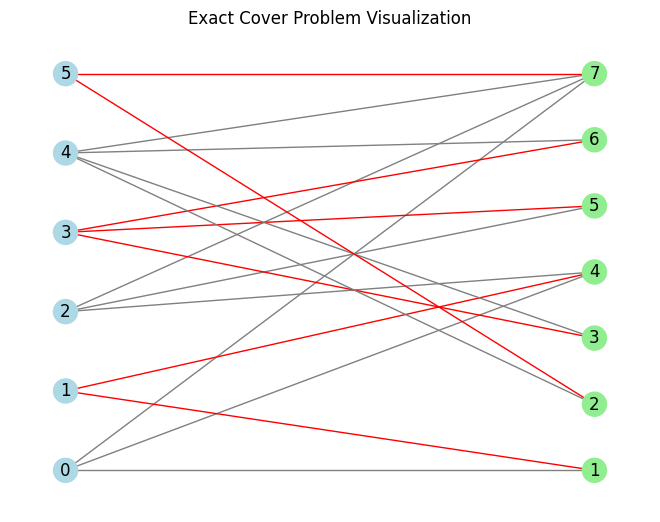

In [7]:
ec = EC.from_preset('toy')
ec.visualize('010101')

## Traveling Salesman
Traveling salesman problem is defined as follows: "Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city". It gets easily visualized by a weighted graph where nodes represent cities while weights represent distances between them. Essentially finding a solution to the Traveling Salesman Problem ie equivalent to finding a permutation of nodes such that the sum of weights associated with edges connecting ech two consecutive nodes is the lowest, i.e. minimizing the objective function:

$$\min C(v) = \sum_{i=1}^{n-1}dist(v_{i},v_{i+1})$$
where $v_{1...n}$ denotes a sequence of nodes such that:
$$\forall_{i,j}(i \not= j) =>(v_{i} \not= v_{j})$$

In quantum launcher encoding a solution to the $N$-node problem uses $N^2$ bits grouped into $N$-bit substrings where each substring denotes, by the use of one-hot-encoding, which node was chosen at a given position in the sequence

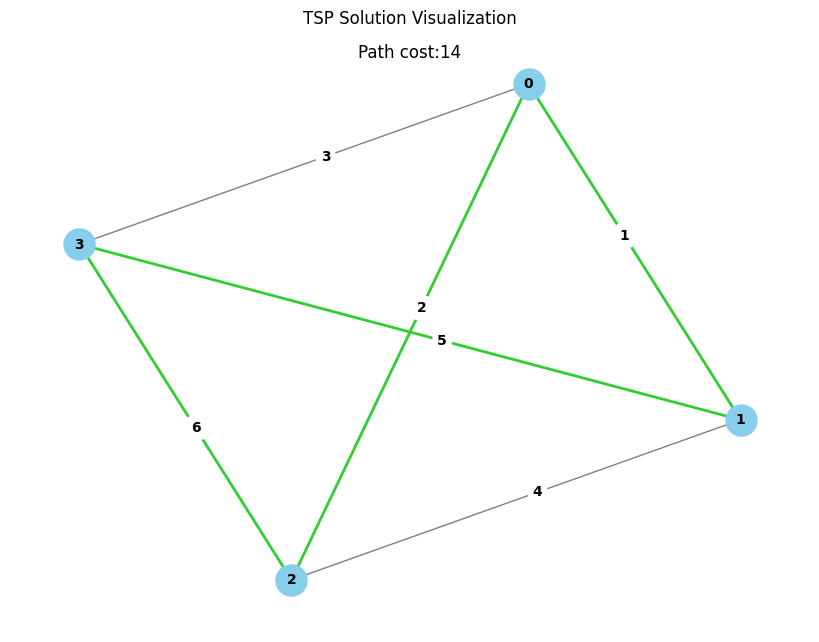

In [8]:
tsp = TSP.from_preset('default')
tsp.visualize('0100100000100001')

## Graph Coloring


Graph coloring refer to the assigning of labels to the  graph' vertices  such that no two vertices sharing the same edge have the same label, although for visualization purposes labels in the form of colors are often used they can generally be of any form. Specifically $k$-coloring is a graph coloring which uses at most $k$ distinct colors. Quantum Launcher implements Minimum Conflict Graph Coloring, an optimization version of the $k$-coloring in which given $k$ available colors the goal is to assign colors to vertices such that a proper coloring is obtained or that the number of occurring conflicts is the lowest, i.e. minimize the objective function:
$$\min C(x)=\sum_{(i, j) \in E} \delta(x_i, x_j)$$
$$\quad \text{where} \quad
\delta(x_i, x_j) = 
\begin{cases}
1 & \text{if } x_i = x_j \\
0 & \text{if } x_i \ne x_j
\end{cases}$$
and x is a sequence of colors such that: $$\forall_{i} x_{i}\in{1...k}$$

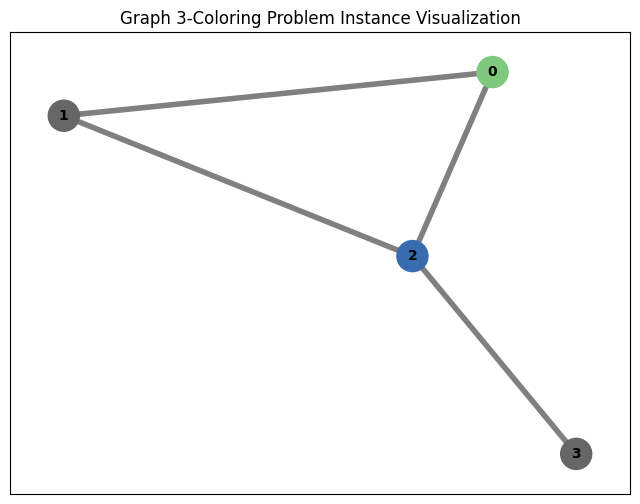

In [9]:
gc = GraphColoring.from_preset('small')
gc.visualize([0,2,1,2])

## Air Traffic Management

Air Traffic management is a combinatorial optimization problem in which a group of aircraft fly through a common airspace, each of them can perform one of the available maneuvers, some of which will result in collision with other aircraft. The goal is to choose a maneuver for every aircraft such that the minimal number of collisions occur.

Input to the problem consists of table of maneuvers available for each aircraft and the matrix of collisions.

In the example below each aircraft has 2 maneuvers available to them represented by "Ax" and "Ax_a=10" where x is an index of the aircraft. When encoded in bitstrings maneuvers are indexed just like in this table e.g. 1 at 0th position means that aircraft no. 0 takes the first from its two maneuvers and 1 at 4th position mean that aircraft no. 1 takes the second of its maneuvers.

In [13]:
filepath = os.path.abspath('./../data/qatm/')
atm = QATM.from_file(filepath,'RCP_3.txt')

print("Aircraft manouvers")
print(atm.instance['aircrafts'])

Aircraft manouvers
  manouver aircraft
0       A0       A0
1       A1       A1
2       A2       A2
3  A0_a=10       A0
4  A1_a=10       A1
5  A2_a=10       A2


The collision matrix which combinations of maneuvers would result in a collision and should be avoided, 1 at $i$'th column and $j$'row indicates that maneuvers i and j happening together result in a collision.

In [ ]:
print("Collisions")
print(atm.instance['cm'])

Collisions
[[1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]
 [0. 1. 0. 0. 0. 1.]]


The proposed encoding means that additional constraint needs to be introduced in order to keep the solutions valid, exactly one of the bits which correspond to maneuvers of a single aircraft must be set to 1, the rest set to 0. The example of a valid solution which results in no collision is presented below:

In [ ]:
print(atm.analyze_result({'011100':1}))

{'collisions': array([0.]), 'onehot_violations': array([0]), 'changes': array([1]), 'at_least_one': array([1])}


## Job Shop Scheduling

In [ ]:
jssp = JSSP.from_preset('toy')
jssp.instance

{'cupcakes': [('mixer', 2), ('oven', 1)],
 'smoothie': [('mixer', 1)],
 'lasagna': [('oven', 2)]}

In [ ]:
from quantum_launcher.launcher import QuantumLauncher
from quantum_launcher.routines.qiskit_routines import QiskitBackend, QAOA

problem = jssp
algorithm = QAOA(p=3)
backend = QiskitBackend('local_simulator')

QuantumLauncher(problem, algorithm, backend).run()

Result(bitstring=0101011, energy=2.3916015625)